# Метод тяжелого шарика Поляка

In [2]:
import sys
from pathlib import Path

src_path = Path("../src").resolve()
sys.path.append(str(src_path))

import numpy as np
from typing import List
import math
from hb import heavy_ball
from mytypes import Array
from show import show
import matplotlib.pyplot as plt
import numpy.typing as npt

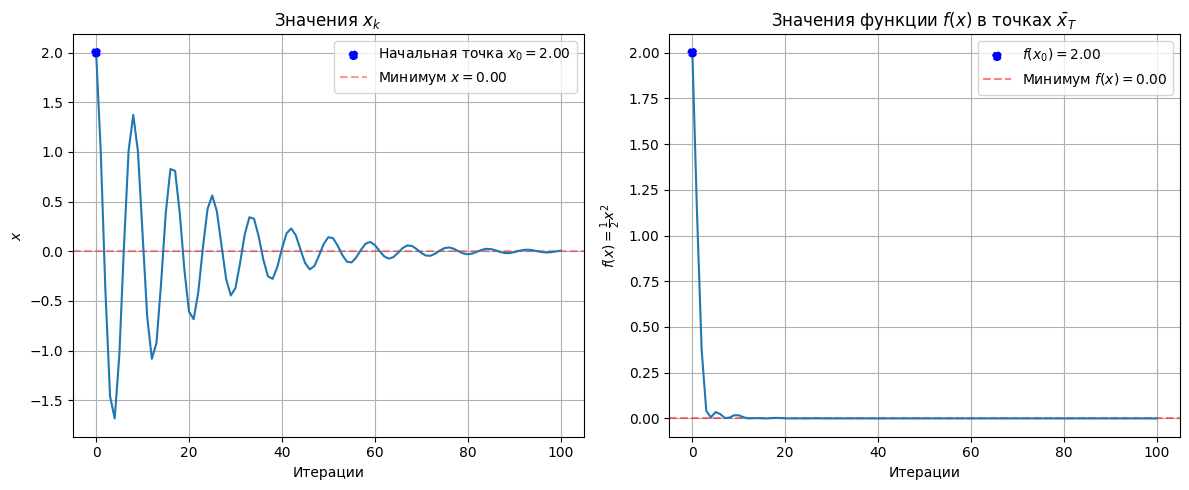

In [3]:
def conv_func_hb(x: Array) -> float:
    return x[0] ** 2 / 2


def grad_conv_func_hb(x: Array) -> Array:
    return np.array([x[0]], dtype=np.float64)


x0: Array = np.array([2.0], dtype=np.float64)
T: int = 100

alpha: float = 0.5
beta: float = 0.9

x_vals: List[Array] = heavy_ball(grad_conv_func_hb, x0, T, alpha, beta)

f_vals: List[float] = []
for k in range(len(x_vals)):
    x_avg: Array = np.mean(np.stack(x_vals[: k + 1], axis=0), axis=0)
    f_vals.append(conv_func_hb(x_avg))

show(
    x_vals,
    f_vals,
    ylabel2=r"$f(x)= \frac{1}{2}x^2$",
    title2=r"Значения функции $f(x)$ в точках $\bar x_T$",
)

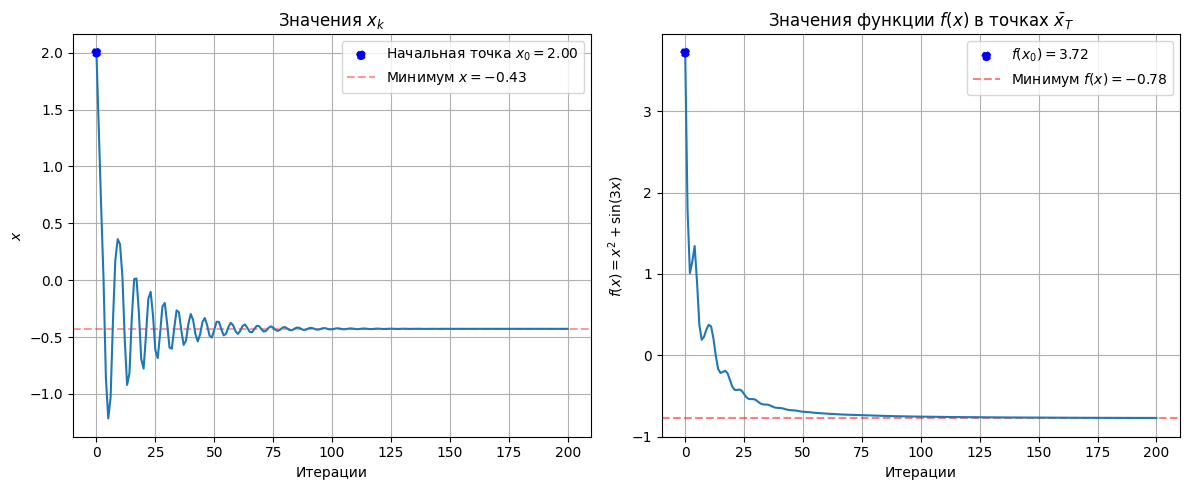

In [4]:
def nonconv_func_hb(x: Array) -> float:
    return x[0] ** 2 + math.sin(3.0 * x[0])


def grad_nonconv_func_hb(x: Array) -> Array:
    return np.array(
        [2.0 * x[0] + 3.0 * math.cos(3.0 * x[0])], dtype=np.float64
    )


x0: Array = np.array([2.0], dtype=np.float64)
T: int = 200
L: float = 11.0
alpha: float = 0.1
beta: float = 0.9

x_vals: List[Array] = heavy_ball(grad_nonconv_func_hb, x0, T, alpha, beta)

f_vals: List[float] = []
for k in range(len(x_vals)):
    x_avg: Array = np.mean(np.stack(x_vals[: k + 1], axis=0), axis=0)
    f_vals.append(nonconv_func_hb(x_avg))

show(
    x_vals,
    f_vals,
    ylabel2=r"$f(x)=x^2 + \sin(3x)$",
    title2=r"Значения функции $f(x)$ в точках $\bar x_T$",
    x_min=-0.427,
    f_min=-0.776,
)

### Пример с нормировкой данных

Перед нормировкой:
L = 125.201, mu = 0.799, kappa = 156.754
Параметры: alpha = 0.027397, beta = 0.726027

После нормировки:
L = 1.447, mu = 0.553, kappa = 2.618
Параметры: alpha = 1.055728, beta = 0.055728


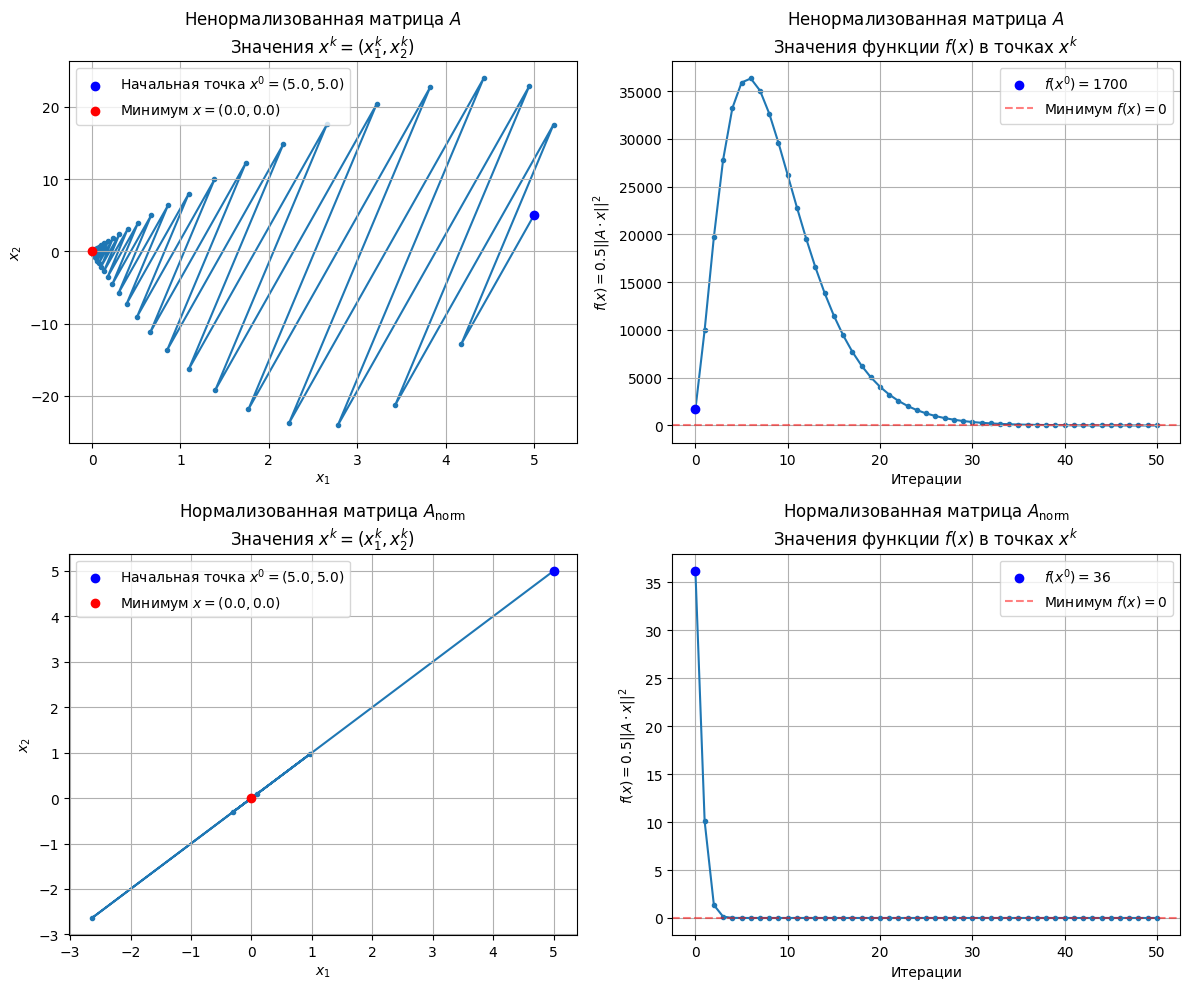

In [5]:
A: Array = np.array([[1.0, 5.0], [0.0, 10.0]], dtype=np.float64)
H: Array = A.T @ A


def grad(x: Array) -> Array:
    return H @ x


n1: float = float(np.linalg.norm(A[:, 0]))
n2: float = float(np.linalg.norm(A[:, 1]))
D: Array = np.diag([n1, n2])
A_n: Array = A @ np.linalg.inv(D)
H_n: Array = A_n.T @ A_n


def grad_norm(x: Array) -> Array:
    return H_n @ x


w: Array
_ = None
w, _ = np.linalg.eig(H)
L: float = float(max(w))
mu: float = float(min(w))
print("Перед нормировкой:")
print(f"L = {L:.3f}, mu = {mu:.3f}, kappa = {L / mu:.3f}")

alpha: float = 4.0 / (np.sqrt(L) + np.sqrt(mu)) ** 2
beta: float = ((np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))) ** 2
print(f"Параметры: alpha = {alpha:.6f}, beta = {beta:.6f}")

w_n: Array
w_n, _ = np.linalg.eig(H_n)
L_n: float = float(max(w_n))
mu_n: float = float(min(w_n))
kappa_n: float = L_n / mu_n
print("\nПосле нормировки:")
print(f"L = {L_n:.3f}, mu = {mu_n:.3f}, kappa = {kappa_n:.3f}")

alpha_n: float = 4.0 / (np.sqrt(L_n) + np.sqrt(mu_n)) ** 2
beta_n: float = (
    (np.sqrt(L_n) - np.sqrt(mu_n)) / (np.sqrt(L_n) + np.sqrt(mu_n))
) ** 2
print(f"Параметры: alpha = {alpha_n:.6f}, beta = {beta_n:.6f}")

x0: Array = np.array([5.0, 5.0], dtype=np.float64)

x_vals: List[Array] = heavy_ball(grad, x0, 50, alpha, beta)
x_vals_norm: List[Array] = heavy_ball(grad_norm, x0, 50, alpha_n, beta_n)


def func(A: Array, x: Array) -> float:
    return 0.5 * float(np.sum((A @ x) ** 2))


f_vals: Array = np.array([func(A, x) for x in x_vals], dtype=np.float64)
f_vals_norm: Array = np.array(
    [func(A_n, x) for x in x_vals_norm], dtype=np.float64
)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

x_vals_arr = np.array(x_vals)

ax[0, 0].plot(x_vals_arr[:, 0], x_vals_arr[:, 1], "-o", markersize=3, zorder=1)
ax[0, 0].set_title(
    r"Ненормализованная матрица $A$" + "\n" + r"Значения $x^k=(x^k_1, x^k_2)$"
)
ax[0, 0].set_xlabel(r"$x_1$")
ax[0, 0].set_ylabel(r"$x_2$")
ax[0, 0].scatter(
    x_vals_arr[0, 0],
    x_vals_arr[0, 1],
    color="blue",
    label=f"Начальная точка $x^0= ({x_vals[0][0]}, {x_vals[0][1]})$",
    zorder=5,
)
ax[0, 0].scatter(0, 0, color="red", label="Минимум $x= (0.0, 0.0)$", zorder=5)
ax[0, 0].legend(loc="upper left")
ax[0, 0].grid(True)

x_vals_norm_arr = np.array(x_vals_norm)

ax[1, 0].plot(
    x_vals_norm_arr[:, 0], x_vals_norm_arr[:, 1], "-o", markersize=3, zorder=1
)
ax[1, 0].set_title(
    r"Нормализованная матрица $A_\text{norm}$"
    + "\n"
    + r"Значения $x^k=(x^k_1, x^k_2)$"
)
ax[1, 0].set_xlabel(r"$x_1$")
ax[1, 0].set_ylabel(r"$x_2$")
ax[1, 0].scatter(
    x_vals_norm_arr[0, 0],
    x_vals_norm_arr[0, 1],
    color="blue",
    label=f"Начальная точка $x^0= ({x_vals_norm[0][0]}, {x_vals_norm[0][1]})$",
    zorder=5,
)
ax[1, 0].scatter(0, 0, color="red", label="Минимум $x= (0.0, 0.0)$", zorder=5)
ax[1, 0].legend()
ax[1, 0].grid(True)

ax[0, 1].plot(f_vals, "-o", markersize=3, zorder=1)
ax[0, 1].set_title(
    r"Ненормализованная матрица $A$"
    + "\n"
    + r"Значения функции $f(x)$ в точках $x^k$"
)
ax[0, 1].set_xlabel("Итерации")
ax[0, 1].set_ylabel(r"$f(x) = 0.5||A \cdot x||^2$")
ax[0, 1].scatter(
    0, f_vals[0], color="blue", label=f"$f(x^0)= {int(f_vals[0])}$", zorder=5
)
ax[0, 1].axhline(
    0, color="red", linestyle="--", alpha=0.5, label=f"Минимум $f(x) = 0$"
)
ax[0, 1].legend()
ax[0, 1].grid(True)

ax[1, 1].plot(f_vals_norm, "-o", markersize=3)
ax[1, 1].set_title(
    r"Нормализованная матрица $A_\text{norm}$"
    + "\n"
    + r"Значения функции $f(x)$ в точках $x^k$"
)
ax[1, 1].set_xlabel("Итерации")
ax[1, 1].set_ylabel(r"$f(x) = 0.5||A \cdot x||^2$")
ax[1, 1].scatter(
    0,
    f_vals_norm[0],
    color="blue",
    label=f"$f(x^0)= {int(f_vals_norm[0])}$",
    zorder=5,
)
ax[1, 1].axhline(
    0, color="red", linestyle="--", alpha=0.5, label=f"Минимум $f(x) = 0$"
)
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()

### Примеры попадания метода Поляка в циклы

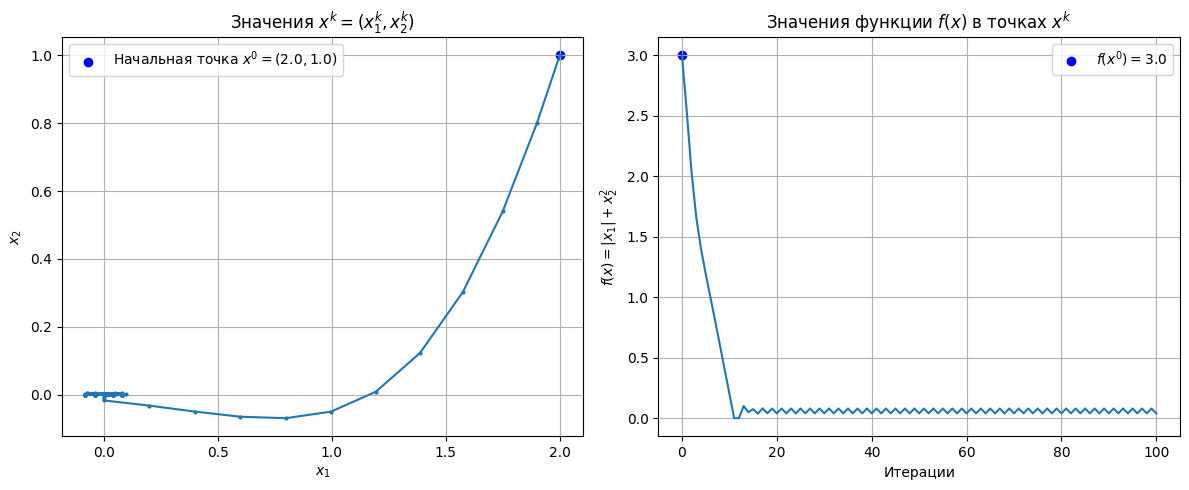

In [6]:
def sum_func_hb(x: Array) -> float:
    return abs(x[0]) + x[1] ** 2


def subgrad_sum_func_hb(x: Array) -> Array:
    return np.array([np.sign(x[0]), 2.0 * x[1]], dtype=np.float64)


x0: Array = np.array([2.0, 1.0], dtype=np.float64)
T: int = 100
alpha: float = 0.1
beta: float = 0.5

x_vals: Array = np.array(
    heavy_ball(subgrad_sum_func_hb, x0, T, alpha, beta), dtype=np.float64
)
f_vals: Array = np.array([sum_func_hb(x) for x in x_vals], dtype=np.float64)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(
    x_vals[0, 0],
    x_vals[0, 1],
    color="blue",
    label=f"Начальная точка $x^0= ({x_vals[0][0]}, {x_vals[0][1]})$",
)
plt.plot(x_vals[:, 0], x_vals[:, 1], "-o", markersize=2)
plt.legend()
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Значения $x^k=(x^k_1, x^k_2)$")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(0, f_vals[0], color="blue", label=f"$f(x^0)= {f_vals[0]}$")
plt.plot(f_vals)
plt.legend()
plt.xlabel("Итерации")
plt.ylabel(r"$f(x) = |x_1| + x_2^2$")
plt.title(r"Значения функции $f(x)$ в точках $x^k$")
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
print("Последние 10 итераций x^k:", "\n", x_vals[-10:])
print("\nПоследние 10 итераций f(x^k):", f_vals[-10:])

Последние 10 итераций x^k: 
 [[-8.00000000e-02  4.55663544e-15]
 [-4.00000000e-02  9.18921631e-15]
 [ 8.00000000e-02  9.66766348e-15]
 [ 4.00000000e-02  7.97335437e-15]
 [-8.00000000e-02  5.53152894e-15]
 [-4.00000000e-02  3.20431044e-15]
 [ 8.00000000e-02  1.39983910e-15]
 [ 4.00000000e-02  2.17635610e-16]
 [-8.00000000e-02 -4.16993257e-16]
 [-4.00000000e-02 -6.50909039e-16]]

Последние 10 итераций f(x^k): [0.08 0.04 0.08 0.04 0.08 0.04 0.08 0.04 0.08 0.04]


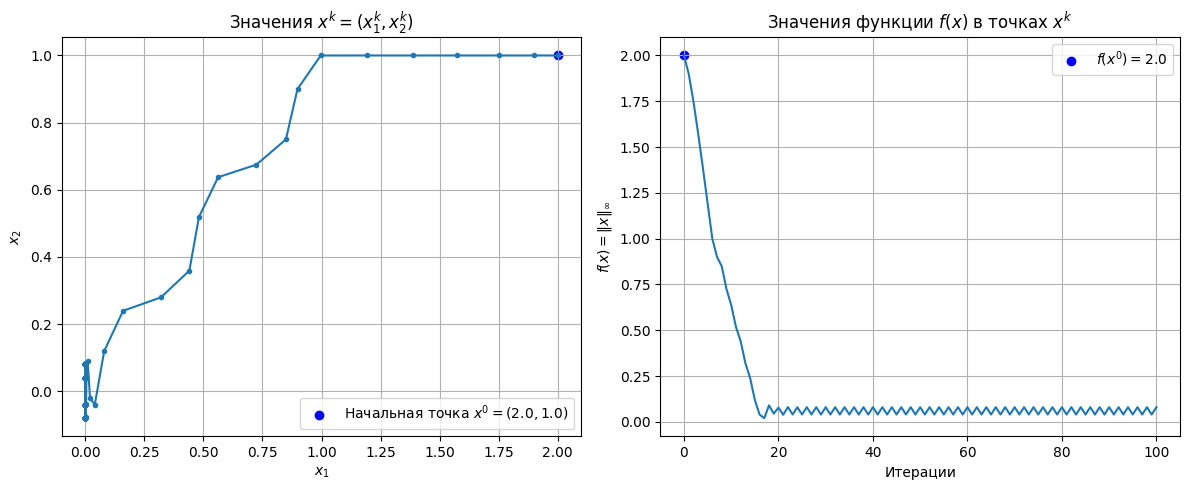

In [8]:
def linf_func_hb(x: Array) -> float:
    return float(np.max(np.abs(x)))


def subgrad_linf_func_hb(x: Array) -> Array:
    abs_x: Array = np.abs(x)

    # Индексы координат, где достигается максимум
    idx: npt.NDArray[np.int_] = np.where(abs_x == np.max(abs_x))[0]
    # Выбираем одну координату
    i: int = int(idx[0])

    # Градиент
    g: Array = np.zeros_like(x)
    g[i] = np.sign(x[i])

    return g


x0: Array = np.array([2.0, 1.0], dtype=np.float64)
T: int = 100
alpha: float = 0.1
beta: float = 0.5

x_vals: Array = np.array(
    heavy_ball(subgrad_linf_func_hb, x0, T, alpha, beta), dtype=np.float64
)
f_vals: Array = np.array([linf_func_hb(x) for x in x_vals], dtype=np.float64)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(
    x_vals[0, 0],
    x_vals[0, 1],
    color="blue",
    label=f"Начальная точка $x^0= ({x_vals[0][0]}, {x_vals[0][1]})$",
)
plt.plot(x_vals[:, 0], x_vals[:, 1], "-o", markersize=3)
plt.legend()
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Значения $x^k=(x^k_1, x^k_2)$")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(0, f_vals[0], color="blue", label=f"$f(x^0)= {f_vals[0]}$")
plt.plot(f_vals)
plt.legend()
plt.xlabel("Итерации")
plt.ylabel(r"$f(x) = \|x\|_\infty$")
plt.title(r"Значения функции $f(x)$ в точках $x^k$")
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
print("Последние 10 итераций x^k:", "\n", x_vals[-10:])
print("\nПоследние 10 итераций f(x^k):", f_vals[-10:])

Последние 10 итераций x^k: 
 [[-2.77555755e-16  4.00000000e-02]
 [-2.77555756e-16 -8.00000000e-02]
 [-2.77555756e-16 -4.00000000e-02]
 [-2.77555756e-16  8.00000000e-02]
 [-2.77555756e-16  4.00000000e-02]
 [-2.77555756e-16 -8.00000000e-02]
 [-2.77555756e-16 -4.00000000e-02]
 [-2.77555756e-16  8.00000000e-02]
 [-2.77555756e-16  4.00000000e-02]
 [-2.77555756e-16 -8.00000000e-02]]

Последние 10 итераций f(x^k): [0.04 0.08 0.04 0.08 0.04 0.08 0.04 0.08 0.04 0.08]
